# Cloud Movement

## Overview

The project loads an ordered image sequence, builds sliding input-target frame windows, trains a ConvLSTM-based predictor, evaluates reconstruction quality, and saves preview images plus training curves.

The code below is kept intact in behavior. It is only split into notebook-friendly sections so you can run, inspect, and visualize each stage more comfortably.

In [1]:
#!/usr/bin/env python
import os
import time
import json
import math
import random
import argparse
from dataclasses import dataclass, asdict
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler




## Imports

These are the original dependencies from the script: computer vision for frame loading, NumPy and Matplotlib for array processing and plotting, and PyTorch for the ConvLSTM model, loss, training loop, and mixed-precision execution.

## Runtime setup

This section defines reproducibility, device selection, startup reporting, and the configuration dataclass used throughout the pipeline.

In [2]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def setup_device(force_cuda: bool = False):
    if force_cuda and not torch.cuda.is_available():
        raise RuntimeError("CUDA was requested but is not available.")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_float32_matmul_precision("high")
    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    return device


def startup_report(device: torch.device, cfg):
    print(f"Device: {device}")
    if device.type == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM_GB: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
        print(f"CUDA: {torch.version.cuda}")
    print(f"AMP: {cfg.amp and device.type == 'cuda'}")
    print(
        f"Config: filters={cfg.filters}, layers={cfg.num_layers}, seq_len={cfg.seq_len}, "
        f"batch_size={cfg.batch_size}, epochs={cfg.epochs}"
    )


@dataclass
class Config:
    data_dir: str = "./BWimages"
    results_dir: str = "./Results_notebook"
    img_h: int = 128
    img_w: int = 128
    img_c: int = 3
    seq_len: int = 8
    stride: int = 1
    filters: int = 96
    ksize: int = 3
    dropout: float = 0.10
    num_layers: int = 2
    decoder_blocks: int = 3
    epochs: int = 40
    batch_size: int = 8
    lr: float = 3e-4
    min_lr: float = 1e-6
    weight_decay: float = 1e-4
    patience: int = 8
    num_workers: int = 0
    grad_clip: float = 1.0
    seed: int = 42
    amp: bool = True
    force_cuda: bool = False
    resume: str = ""




## Data pipeline

These functions scan the image directory, load and resize frames, create sliding time windows, split them into train/validation/test partitions, and wrap them in a PyTorch dataset.

In [3]:
def valid_image_files(data_dir: str):
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    root = Path(data_dir)
    if not root.exists():
        raise FileNotFoundError(f"Data directory not found: {root.resolve()}")
    files = sorted([p for p in root.iterdir() if p.is_file() and p.suffix.lower() in exts])
    if not files:
        raise ValueError(f"No image files found in {root.resolve()}")
    return files


def load_frames(cfg: Config):
    files = valid_image_files(cfg.data_dir)
    frames = []
    bad_files = []
    for path in files:
        img = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if img is None:
            bad_files.append(path.name)
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (cfg.img_w, cfg.img_h), interpolation=cv2.INTER_AREA)
        frames.append(img.astype(np.float32) / 255.0)
    if not frames:
        raise ValueError("No readable images were loaded.")
    frames = np.stack(frames).astype(np.float32)
    return frames, bad_files


def build_pairs(frames: np.ndarray, seq_len: int, stride: int):
    if len(frames) < seq_len + 1:
        raise ValueError(f"Need at least {seq_len + 1} frames, got {len(frames)}.")
    X, Y = [], []
    for i in range(0, len(frames) - seq_len, stride):
        X.append(frames[i:i + seq_len])
        Y.append(frames[i + 1:i + seq_len + 1])
    return np.stack(X), np.stack(Y)


def split_pairs(X, Y, train_ratio=0.7, val_ratio=0.15):
    n = len(X)
    if n < 6:
        raise ValueError(f"Too few sequence pairs: {n}")
    n_train = max(2, int(n * train_ratio))
    n_val = max(2, int(n * val_ratio))
    n_test = n - n_train - n_val
    if n_test < 2:
        n_test = 2
        n_train = n - n_val - n_test
    i1 = n_train
    i2 = n_train + n_val
    return {
        "train": (X[:i1], Y[:i1]),
        "val": (X[i1:i2], Y[i1:i2]),
        "test": (X[i2:], Y[i2:]),
    }


class SequenceDataset(Dataset):
    def __init__(self, X, Y, augment=False):
        self.X = torch.from_numpy(X.transpose(0, 1, 4, 2, 3)).float()
        self.Y = torch.from_numpy(Y.transpose(0, 1, 4, 2, 3)).float()
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.Y[idx]
        if self.augment:
            if torch.rand(1).item() > 0.5:
                x, y = x.flip(-1), y.flip(-1)
            if torch.rand(1).item() > 0.5:
                x, y = x.flip(-2), y.flip(-2)
        return x, y




## Data preview helpers

This extra notebook-only cell does not change the original training code. It gives you a convenient way to preview raw frames, verify ordering, and inspect the generated sequence shapes before committing to a full training run.

In [4]:

# Notebook helper cell: preview raw frames and sample sequences.
# Run after creating a Config and loading frames.

def notebook_preview_frames(frames, max_cols=5, title='Sample frames'):
    n = min(len(frames), max_cols)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]
    for i in range(n):
        axes[i].imshow(frames[i])
        axes[i].set_title(f'Frame {i}')
        axes[i].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def notebook_preview_pair(X, Y, pair_idx=0, max_steps=4):
    t = min(X.shape[1], max_steps)
    fig, axes = plt.subplots(2, t, figsize=(4*t, 6))
    if t == 1:
        axes = np.array(axes).reshape(2, 1)
    for i in range(t):
        axes[0, i].imshow(X[pair_idx, i])
        axes[0, i].set_title(f'Input {i}')
        axes[0, i].axis('off')
        axes[1, i].imshow(Y[pair_idx, i])
        axes[1, i].set_title(f'Target {i}')
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()


## Model

The network combines stacked ConvLSTM layers for temporal-spatial encoding, residual refinement blocks for feature polishing, and a sigmoid output head for frame prediction.

In [5]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, ksize=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, ksize, padding=ksize // 2)

    def forward(self, x, h, c):
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, g, o = gates.chunk(4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.tanh(g)
        o = torch.sigmoid(o)
        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c

    def init_hidden(self, batch_size, height, width, device, dtype):
        h = torch.zeros(batch_size, self.hid_ch, height, width, device=device, dtype=dtype)
        c = torch.zeros(batch_size, self.hid_ch, height, width, device=device, dtype=dtype)
        return h, c


class StackedConvLSTM(nn.Module):
    def __init__(self, in_ch, hid_ch, n_layers, ksize=3, drop=0.1):
        super().__init__()
        self.cells = nn.ModuleList([
            ConvLSTMCell(in_ch if i == 0 else hid_ch, hid_ch, ksize)
            for i in range(n_layers)
        ])
        groups = 8 if hid_ch % 8 == 0 else 1
        self.norms = nn.ModuleList([nn.GroupNorm(groups, hid_ch) for _ in range(n_layers)])
        self.dropout = nn.Dropout2d(drop)

    def forward(self, x):
        B, T, _, H, W = x.shape
        states = [cell.init_hidden(B, H, W, x.device, x.dtype) for cell in self.cells]
        outputs = []
        for t in range(T):
            inp = x[:, t]
            for layer_idx, (cell, norm) in enumerate(zip(self.cells, self.norms)):
                h, c = cell(inp, *states[layer_idx])
                h = norm(h)
                states[layer_idx] = (h, c)
                inp = self.dropout(h) if layer_idx < len(self.cells) - 1 else h
            outputs.append(h.unsqueeze(1))
        return torch.cat(outputs, dim=1)


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        groups = 8 if channels % 8 == 0 else 1
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.GroupNorm(groups, channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.GroupNorm(groups, channels),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class ConvLSTMPredictorV2(nn.Module):
    def __init__(self, in_ch, hid_ch, n_layers, ksize=3, drop=0.1, decoder_blocks=3):
        super().__init__()
        self.encoder = StackedConvLSTM(in_ch, hid_ch, n_layers, ksize, drop)
        self.refine = nn.Sequential(*[ResidualBlock(hid_ch) for _ in range(decoder_blocks)])
        self.head = nn.Sequential(
            nn.Conv2d(hid_ch, hid_ch, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(hid_ch, in_ch, 1),
        )

    def forward(self, x):
        feats = self.encoder(x)
        B, T, C, H, W = feats.shape
        y = feats.reshape(B * T, C, H, W)
        y = self.refine(y)
        y = self.head(y)
        return torch.sigmoid(y.reshape(B, T, -1, H, W))




## Loss and evaluation

The objective mixes pixel, edge, and SSIM-based terms. Evaluation also reports MAE, PSNR, and SSIM so training quality can be judged from several angles instead of a single loss value.

In [6]:
def gaussian_kernel(window_size=11, sigma=1.5, channels=3, device="cpu", dtype=torch.float32):
    coords = torch.arange(window_size, device=device, dtype=dtype) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel_2d = (g[:, None] @ g[None, :]).unsqueeze(0).unsqueeze(0)
    kernel_2d = kernel_2d.expand(channels, 1, window_size, window_size).contiguous()
    return kernel_2d


def ssim_score(pred, target, window_size=11, sigma=1.5):
    B, T, C, H, W = pred.shape
    x = pred.reshape(B * T, C, H, W)
    y = target.reshape(B * T, C, H, W).to(dtype=x.dtype)
    kernel = gaussian_kernel(window_size, sigma, C, x.device, x.dtype)
    padding = window_size // 2

    mu_x = F.conv2d(x, kernel, padding=padding, groups=C)
    mu_y = F.conv2d(y, kernel, padding=padding, groups=C)

    mu_x2 = mu_x.pow(2)
    mu_y2 = mu_y.pow(2)
    mu_xy = mu_x * mu_y

    sigma_x2 = F.conv2d(x * x, kernel, padding=padding, groups=C) - mu_x2
    sigma_y2 = F.conv2d(y * y, kernel, padding=padding, groups=C) - mu_y2
    sigma_xy = F.conv2d(x * y, kernel, padding=padding, groups=C) - mu_xy

    c1 = x.new_tensor(0.01 ** 2)
    c2 = x.new_tensor(0.03 ** 2)

    ssim_map = ((2 * mu_xy + c1) * (2 * sigma_xy + c2)) / (
        (mu_x2 + mu_y2 + c1) * (sigma_x2 + sigma_y2 + c2) + x.new_tensor(1e-8)
    )
    return ssim_map.mean().float()


class V2Loss(nn.Module):
    def __init__(self, alpha=0.55, beta=0.20, gamma=0.25):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.pixel = nn.SmoothL1Loss(beta=0.05)

    def gradient_loss(self, pred, target):
        dy_p = pred[:, :, :, 1:, :] - pred[:, :, :, :-1, :]
        dx_p = pred[:, :, :, :, 1:] - pred[:, :, :, :, :-1]
        dy_t = target[:, :, :, 1:, :] - target[:, :, :, :-1, :]
        dx_t = target[:, :, :, :, 1:] - target[:, :, :, :, :-1]
        return (dy_p - dy_t).abs().mean() + (dx_p - dx_t).abs().mean()

    def forward(self, pred, target):
        pixel = self.pixel(pred, target)
        edge = self.gradient_loss(pred, target)
        ssim_term = 1.0 - ssim_score(pred, target)
        total = self.alpha * pixel + self.beta * edge + self.gamma * ssim_term
        stats = {
            "pixel": float(pixel.detach().item()),
            "edge": float(edge.detach().item()),
            "ssim_loss": float(ssim_term.detach().item()),
        }
        return total, stats


def make_loader(ds, batch_size, shuffle, num_workers, pin_memory):
    kwargs = dict(
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    if num_workers > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2
    return DataLoader(ds, **kwargs)


def psnr(pred, target):
    mse = torch.mean((pred - target) ** 2).item()
    if mse <= 1e-12:
        return 99.0
    return float(20.0 * math.log10(1.0 / math.sqrt(mse)))


def evaluate(model, loader, criterion, device, use_amp):
    model.eval()
    total_loss = 0.0
    total_mae = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    preds_all = []
    targets_all = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type=device.type, enabled=use_amp):
                pred = model(xb)
                loss, _ = criterion(pred, yb)
            total_loss += loss.item()
            total_mae += (pred - yb).abs().mean().item()
            total_psnr += psnr(pred, yb)
            total_ssim += float(ssim_score(pred, yb).item())
            preds_all.append(pred.float().cpu())
            targets_all.append(yb.float().cpu())

    return {
        "loss": total_loss / max(1, len(loader)),
        "mae": total_mae / max(1, len(loader)),
        "psnr": total_psnr / max(1, len(loader)),
        "ssim": total_ssim / max(1, len(loader)),
        "preds": torch.cat(preds_all, dim=0),
        "targets": torch.cat(targets_all, dim=0),
    }




## Visualization outputs

These original helper functions save training curves and prediction previews to disk. In notebook use, the files can also be displayed inline after they are generated.

In [7]:
def save_curves(history, out_dir: Path):
    steps = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].plot(steps, history["train_loss"], label="Train", linewidth=2)
    axes[0].plot(steps, history["val_loss"], label="Val", linewidth=2)
    axes[0].set_title("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(steps, history["train_mae"], label="Train", linewidth=2)
    axes[1].plot(steps, history["val_mae"], label="Val", linewidth=2)
    axes[1].set_title("MAE")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    axes[2].plot(steps, history["val_psnr"], label="Val PSNR", linewidth=2)
    axes[2].plot(steps, history["val_ssim"], label="Val SSIM", linewidth=2)
    axes[2].set_title("Validation Quality")
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(out_dir / "training_curves.png", dpi=140, bbox_inches="tight")
    plt.close(fig)


def save_preview(inputs, preds, targets, out_dir: Path):
    t_steps = min(4, inputs.shape[1])
    fig, axes = plt.subplots(3, t_steps, figsize=(4 * t_steps, 8))
    if t_steps == 1:
        axes = np.array(axes).reshape(3, 1)

    for t in range(t_steps):
        axes[0, t].imshow(inputs[0, t].permute(1, 2, 0).cpu().numpy().clip(0, 1))
        axes[0, t].set_title(f"Input {t}")
        axes[1, t].imshow(preds[0, t].permute(1, 2, 0).cpu().numpy().clip(0, 1))
        axes[1, t].set_title(f"Pred {t}")
        axes[2, t].imshow(targets[0, t].permute(1, 2, 0).cpu().numpy().clip(0, 1))
        axes[2, t].set_title(f"Target {t}")
        for r in range(3):
            axes[r, t].axis("off")

    plt.tight_layout()
    plt.savefig(out_dir / "predictions_preview.png", dpi=140, bbox_inches="tight")
    plt.close(fig)




## Training entry point

This is the original training and evaluation flow: build loaders, create the model, train with early stopping, reload the best checkpoint, evaluate on the test split, and write result artifacts.

In [8]:
def maybe_resume(model, optimizer, scheduler, scaler, resume_path, device):
    start_epoch = 1
    best_val = float("inf")
    if resume_path:
        ckpt = torch.load(resume_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        if "optimizer_state_dict" in ckpt:
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        if "scheduler_state_dict" in ckpt:
            scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        if "scaler_state_dict" in ckpt:
            scaler.load_state_dict(ckpt["scaler_state_dict"])
        start_epoch = int(ckpt.get("epoch", 0)) + 1
        best_val = float(ckpt.get("best_val", best_val))
        print(f"Resumed from {resume_path} at epoch {start_epoch - 1}")
    return start_epoch, best_val


def main(cfg: Config):
    seed_everything(cfg.seed)
    device = setup_device(cfg.force_cuda)
    startup_report(device, cfg)
    use_amp = bool(cfg.amp and device.type == "cuda")

    out_dir = Path(cfg.results_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = out_dir / "best_model_v2.pt"

    frames, bad_files = load_frames(cfg)
    X, Y = build_pairs(frames, cfg.seq_len, cfg.stride)
    splits = split_pairs(X, Y)

    train_ds = SequenceDataset(*splits["train"], augment=True)
    val_ds = SequenceDataset(*splits["val"], augment=False)
    test_ds = SequenceDataset(*splits["test"], augment=False)

    print(f"Frames: {len(frames)} | Pairs: {len(X)}")
    print(f"Splits: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

    train_loader = make_loader(train_ds, cfg.batch_size, True, cfg.num_workers, device.type == "cuda")
    val_loader = make_loader(val_ds, cfg.batch_size, False, cfg.num_workers, device.type == "cuda")
    test_loader = make_loader(test_ds, cfg.batch_size, False, cfg.num_workers, device.type == "cuda")

    model = ConvLSTMPredictorV2(
        cfg.img_c,
        cfg.filters,
        cfg.num_layers,
        cfg.ksize,
        cfg.dropout,
        cfg.decoder_blocks,
    ).to(device)

    criterion = V2Loss(alpha=0.70, beta=0.20, gamma=0.10)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=cfg.epochs,
        eta_min=cfg.min_lr,
    )
    scaler = GradScaler(device=device.type, enabled=use_amp)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mae": [],
        "val_mae": [],
        "val_psnr": [],
        "val_ssim": [],
    }

    start_epoch, best_val = maybe_resume(model, optimizer, scheduler, scaler, cfg.resume, device)
    bad_epochs = 0
    sample_x = None
    start = time.time()

    for epoch in range(start_epoch, cfg.epochs + 1):
        model.train()
        running_loss = 0.0
        running_mae = 0.0
        running_pixel = 0.0
        running_edge = 0.0
        running_ssim_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=device.type, enabled=use_amp):
                pred = model(xb)
                loss, loss_stats = criterion(pred, yb)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            running_mae += (pred.detach() - yb).abs().mean().item()
            running_pixel += loss_stats["pixel"]
            running_edge += loss_stats["edge"]
            running_ssim_loss += loss_stats["ssim_loss"]

            if sample_x is None:
                sample_x = xb[:1].detach().float().cpu()

        train_loss = running_loss / max(1, len(train_loader))
        train_mae = running_mae / max(1, len(train_loader))
        train_pixel = running_pixel / max(1, len(train_loader))
        train_edge = running_edge / max(1, len(train_loader))
        train_ssim_loss = running_ssim_loss / max(1, len(train_loader))

        val_stats = evaluate(model, val_loader, criterion, device, use_amp)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_stats["loss"])
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_stats["mae"])
        history["val_psnr"].append(val_stats["psnr"])
        history["val_ssim"].append(val_stats["ssim"])

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d}/{cfg.epochs:03d} | train_loss={train_loss:.4f} | "
            f"val_loss={val_stats['loss']:.4f} | train_mae={train_mae:.4f} | "
            f"val_mae={val_stats['mae']:.4f} | val_psnr={val_stats['psnr']:.2f} | "
            f"val_ssim={val_stats['ssim']:.4f} | pixel={train_pixel:.4f} | "
            f"edge={train_edge:.4f} | ssim_loss={train_ssim_loss:.4f} | lr={lr_now:.2e}"
        )

        if val_stats["loss"] < best_val:
            best_val = val_stats["loss"]
            bad_epochs = 0
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "scaler_state_dict": scaler.state_dict(),
                    "best_val": best_val,
                    "config": asdict(cfg),
                },
                ckpt_path,
            )
        else:
            bad_epochs += 1
            if bad_epochs >= cfg.patience:
                print(f"Early stopping at epoch {epoch}.")
                break

    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    test_stats = evaluate(model, test_loader, criterion, device, use_amp)

    save_curves(history, out_dir)
    if sample_x is not None:
        save_preview(sample_x, test_stats["preds"][:1], test_stats["targets"][:1], out_dir)

    metrics = {
        "device": str(device),
        "gpu_name": torch.cuda.get_device_name(0) if device.type == "cuda" else None,
        "frames": int(len(frames)),
        "pairs": int(len(X)),
        "splits": {"train": len(train_ds), "val": len(val_ds), "test": len(test_ds)},
        "bad_files": bad_files,
        "best_val_loss": float(best_val),
        "test_loss": float(test_stats["loss"]),
        "test_mae": float(test_stats["mae"]),
        "test_psnr": float(test_stats["psnr"]),
        "test_ssim": float(test_stats["ssim"]),
        "seconds": float(time.time() - start),
        "config": asdict(cfg),
    }

    with open(out_dir / "metrics_v2.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    with open(out_dir / "run_info_v2.txt", "w", encoding="utf-8") as f:
        for k, v in metrics.items():
            f.write(f"{k}: {v}\n")

    print(
        json.dumps(
            {
                "best_val_loss": best_val,
                "test_loss": test_stats["loss"],
                "test_mae": test_stats["mae"],
                "test_psnr": test_stats["psnr"],
                "test_ssim": test_stats["ssim"],
            },
            indent=2,
        )
    )




## Run configuration

Create a config here, adjust paths or hyperparameters if needed, and then run the next cells step by step. This keeps the original code untouched while making experimentation easier.

In [9]:

# Example notebook configuration
cfg = Config(
    data_dir='./BWimages',
    results_dir='./Results_notebook',
    img_h=128,
    img_w=128,
    img_c=3,
    seq_len=8,
    stride=1,
    filters=96,
    ksize=3,
    dropout=0.10,
    num_layers=2,
    decoder_blocks=3,
    epochs=40,
    batch_size=8,
    lr=3e-4,
    min_lr=1e-6,
    weight_decay=1e-4,
    patience=8,
    num_workers=0,
    grad_clip=1.0,
    seed=42,
    amp=True,
    force_cuda=False,
    resume=''
)
cfg


Config(data_dir='./BWimages', results_dir='./Results_notebook', img_h=128, img_w=128, img_c=3, seq_len=8, stride=1, filters=96, ksize=3, dropout=0.1, num_layers=2, decoder_blocks=3, epochs=40, batch_size=8, lr=0.0003, min_lr=1e-06, weight_decay=0.0001, patience=8, num_workers=0, grad_clip=1.0, seed=42, amp=True, force_cuda=False, resume='')

## Inspect data

Use this section to load frames and inspect both the raw image sequence and the generated training pairs. It helps catch data-order or preprocessing issues early.

Frames: 248
Bad files: []
X shape: (240, 8, 128, 128, 3)
Y shape: (240, 8, 128, 128, 3)
Split sizes: {'train': 168, 'val': 36, 'test': 36}


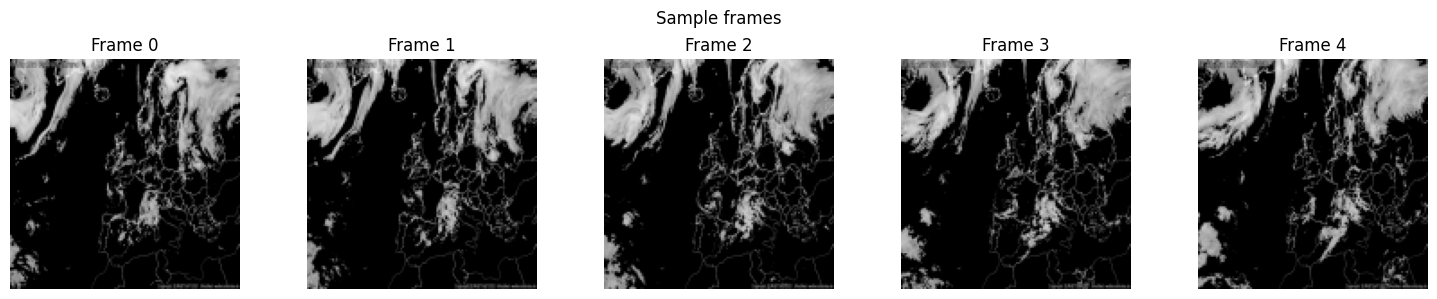

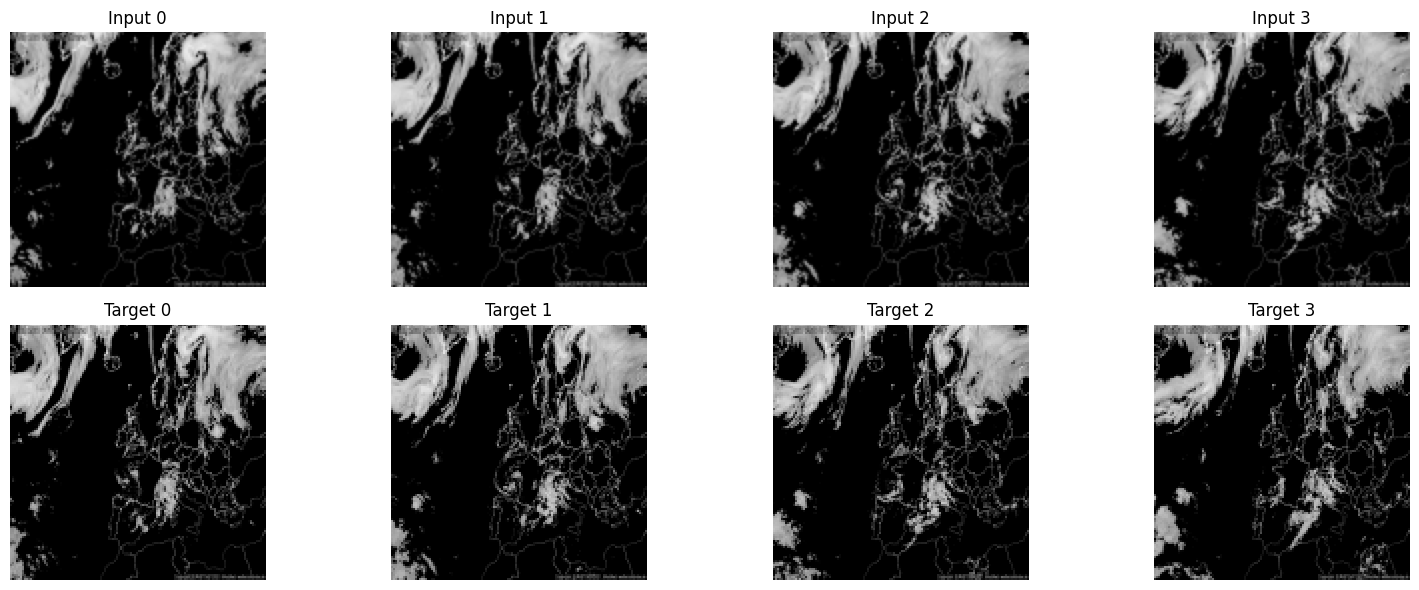

In [10]:

frames, bad_files = load_frames(cfg)
X, Y = build_pairs(frames, cfg.seq_len, cfg.stride)
splits = split_pairs(X, Y)

print('Frames:', len(frames))
print('Bad files:', bad_files)
print('X shape:', X.shape)
print('Y shape:', Y.shape)
print('Split sizes:', {k: len(v[0]) for k, v in splits.items()})

notebook_preview_frames(frames)
notebook_preview_pair(X, Y, pair_idx=0)


## Train the model

Run the original `main` function exactly as written. This preserves the script behavior while benefiting from notebook interactivity.

In [11]:
main(cfg)


c:\Users\Adrian\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\__init__.py:1605: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  _C._set_float32_matmul_precision(precision)


Device: cuda
GPU: NVIDIA GeForce RTX 5090 Laptop GPU
VRAM_GB: 25.65
CUDA: 12.9
AMP: True
Config: filters=96, layers=2, seq_len=8, batch_size=8, epochs=40
Frames: 248 | Pairs: 240
Splits: train=168, val=36, test=36
Epoch 001/040 | train_loss=0.2231 | val_loss=0.2077 | train_mae=0.1835 | val_mae=0.1649 | val_psnr=12.15 | val_ssim=0.2454 | pixel=0.1652 | edge=0.1525 | ssim_loss=0.7702 | lr=3.00e-04
Epoch 002/040 | train_loss=0.1788 | val_loss=0.1611 | train_mae=0.1355 | val_mae=0.1163 | val_psnr=14.22 | val_ssim=0.3720 | pixel=0.1193 | edge=0.1508 | ssim_loss=0.6514 | lr=2.98e-04
Epoch 003/040 | train_loss=0.1540 | val_loss=0.1551 | train_mae=0.1111 | val_mae=0.1130 | val_psnr=14.54 | val_ssim=0.4060 | pixel=0.0954 | edge=0.1505 | ssim_loss=0.5719 | lr=2.96e-04
Epoch 004/040 | train_loss=0.1484 | val_loss=0.1512 | train_mae=0.1082 | val_mae=0.1117 | val_psnr=14.54 | val_ssim=0.4368 | pixel=0.0926 | edge=0.1496 | ssim_loss=0.5366 | lr=2.93e-04
Epoch 005/040 | train_loss=0.1433 | val_loss=0

## Display saved artifacts

After training finishes, this notebook-only cell renders the saved preview image and training curve image directly inside the notebook for a smoother analysis workflow.

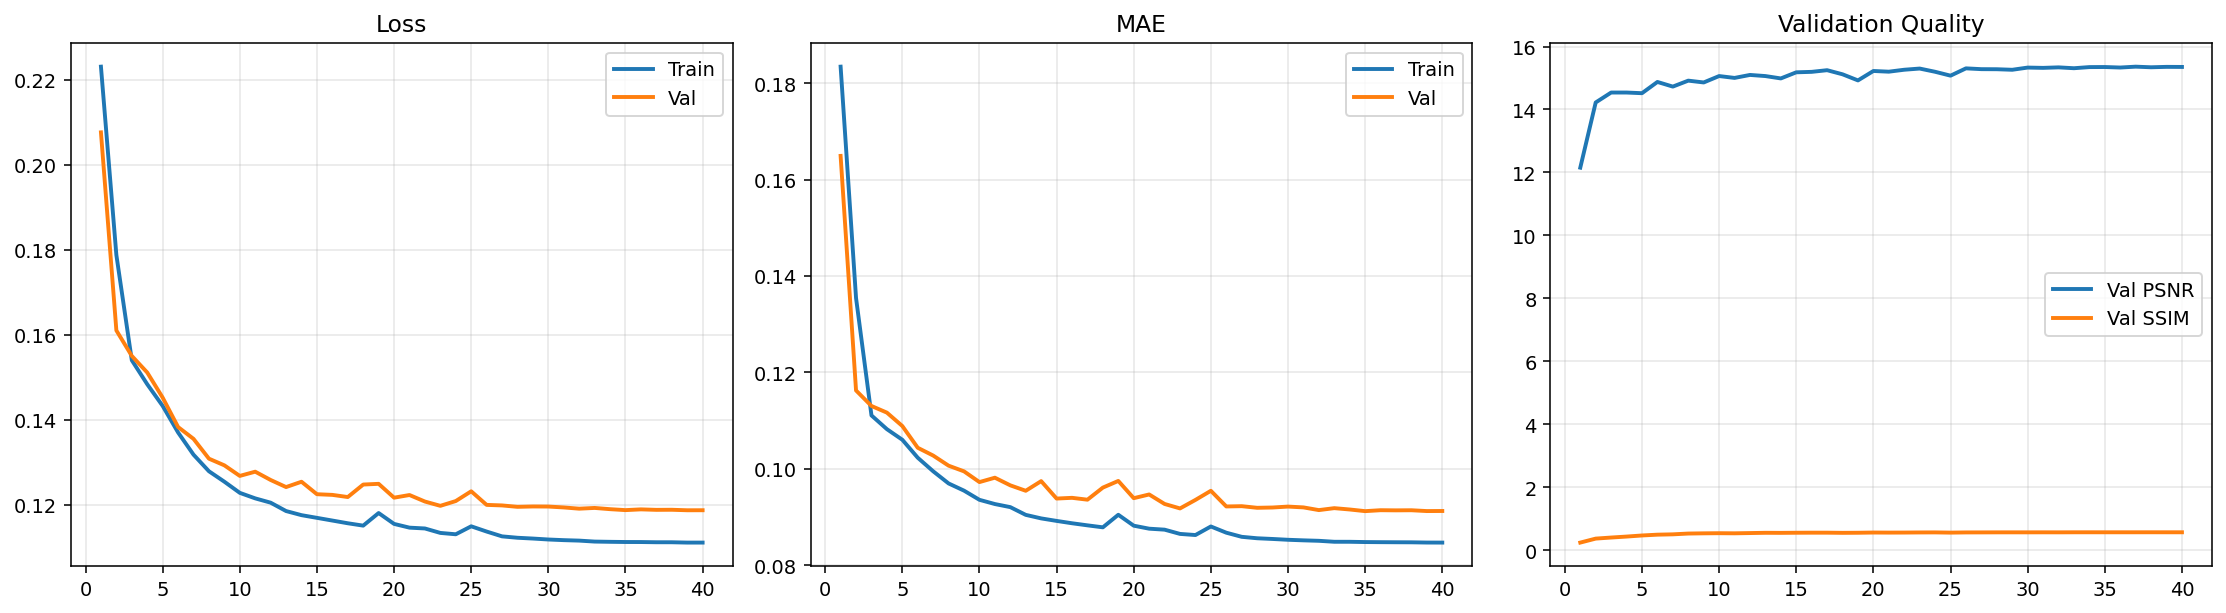

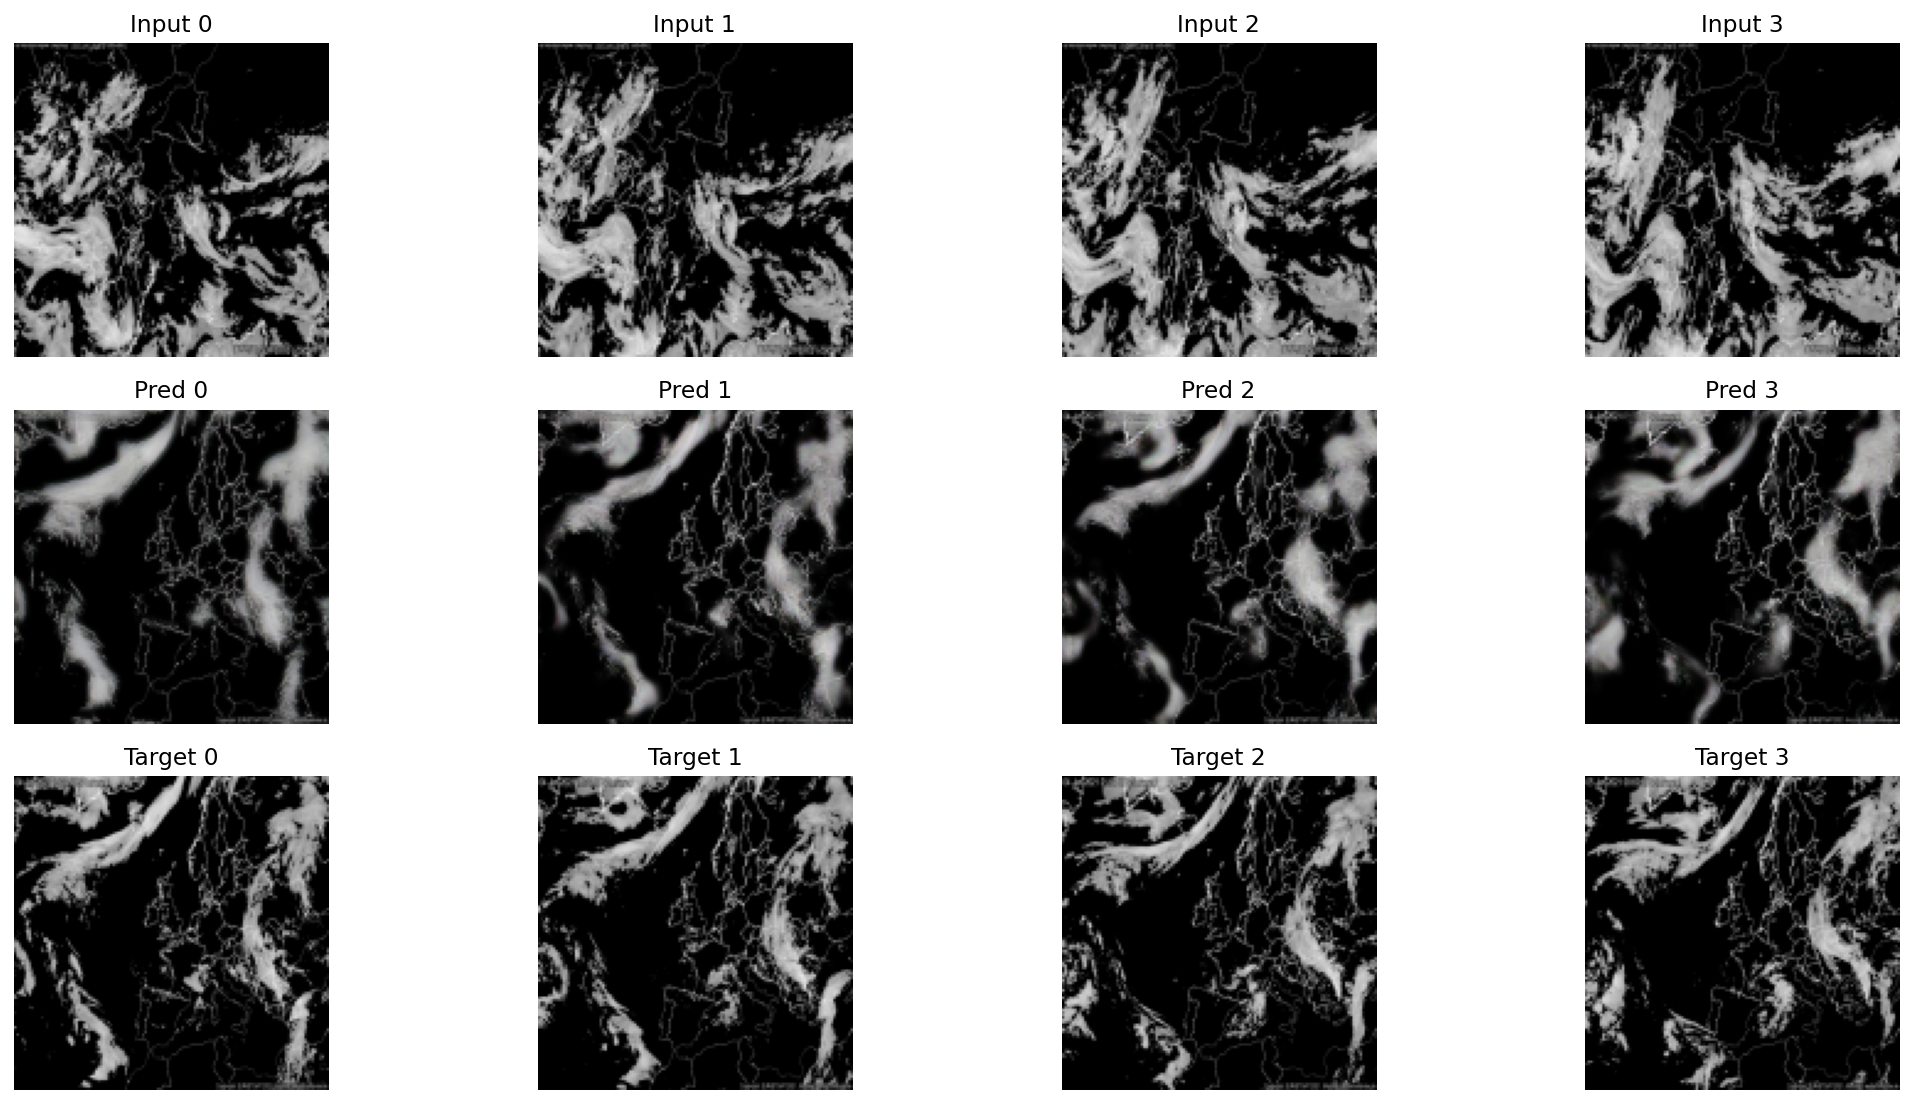

In [12]:

from IPython.display import display, Image
from pathlib import Path

out_dir = Path(cfg.results_dir)
for name in ['training_curves.png', 'predictions_preview.png']:
    path = out_dir / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'Missing: {path}')
